#### visualization of result for ablation analysis 

In [1]:
import glob
import numpy as np
import pandas as pd
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from notebooks import config
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from utils.imgShow import imsShow, imgShow
from matplotlib.colors import ListedColormap 
from matplotlib.colors import LinearSegmentedColormap


### (1) method ablation

In [2]:
paths_val_scene = config.paths_scene_val
paths_val_truth = config.paths_truth_val
paths_val_dem = config.paths_dem_val
dir_result_1branch = 'data/result/ablation_module/unet_timm/'
dir_result_2branch = 'data/result/ablation_module/u2net_timm/'
dir_result_3branch = 'data/result/ablation_module/u3net_timm/'
dir_result_3branch_cafm = 'data/result/u3net_cross_fusion/'
paths_val_result_1branch = sorted(glob.glob(dir_result_1branch + '*.tif'))
paths_val_result_2branch = sorted(glob.glob(dir_result_2branch + '*.tif'))
paths_val_result_3branch = sorted(glob.glob(dir_result_3branch + '*.tif'))
paths_val_result_3branch_cafm = sorted(glob.glob(dir_result_3branch_cafm + '*.tif'))
print(len(paths_val_result_3branch_cafm))



13


In [3]:
colors_gla = [
    (31/255, 36/255, 42/255),     # 非冰川：暗灰
    (140/255, 230/255, 255/255)   # 冰川：明亮冰蓝
    ]
colors_result = [
    (255/255, 255/255, 0/255),     # omission, value = -1, 黄色
    (31/255, 36/255, 42/255),     # non-glacier, value = 0， 深灰
    (140/255, 230/255, 255/255),   # glacier,  value = 1， 亮蓝
    (255/255, 0/255, 0/255),      # commission, value = 2， 红色
    ]
cmap_gla = ListedColormap(colors_gla)
cmap_result = ListedColormap(colors_result)



In [4]:
## (1) read scenes and truths
scenes_rio, scenes_arr, truths, dems = [], [], [], []
for path_scene, path_truth, path_dem in zip(paths_val_scene, paths_val_truth, paths_val_dem):   
    with rio.open(path_scene) as scene_rio:
        scene_arr = scene_rio.read()  
        scene_arr = scene_arr.transpose((1, 2, 0))   ## (H,W,C)
        scenes_rio.append(scene_rio)
        scenes_arr.append(scene_arr)
    with rio.open(path_truth) as truth_rio:
        truth_arr = truth_rio.read()[0]             ## (H,W)
        profile_truth = truth_rio.profile
        truths.append(truth_arr)    
    with rio.open(path_dem) as dem_rio:
        dem_arr = dem_rio.read()[0]                 ## (H,W)
        profile_dem = dem_rio.profile 
        dems.append(dem_arr)


In [5]:
### read results
results_1b, results_2b, results_3b, results_3b_cafm = [], [], [], []
for path_result_1b, path_result_2b, path_result_3b, path_result_3b_cafm in zip(paths_val_result_1branch, paths_val_result_2branch, paths_val_result_3branch, paths_val_result_3branch_cafm):
    with rio.open(path_result_1b) as result_rio:
        result_arr = result_rio.read()[0]
        results_1b.append(result_arr)
    with rio.open(path_result_2b) as result_rio:
        result_arr = result_rio.read()[0]
        results_2b.append(result_arr)
    with rio.open(path_result_3b) as result_rio:
        result_arr = result_rio.read()[0]
        results_3b.append(result_arr)
    with rio.open(path_result_3b_cafm) as result_rio:
        result_arr = result_rio.read()[0]
        results_3b_cafm.append(result_arr)


In [6]:
acc_metrics_1b = pd.read_csv(dir_result_1branch + 'metrics_scenes.csv')
acc_metrics_2b = pd.read_csv(dir_result_2branch + 'metrics_scenes.csv')
acc_metrics_3b = pd.read_csv(dir_result_3branch + 'metrics_scenes.csv')
acc_metrics_3b_cafm = pd.read_csv(dir_result_3branch_cafm + 'metrics_scenes.csv')
acc_model = pd.DataFrame({
    "1b": acc_metrics_1b[["miou", 'precision', 'recall']].mean(),
    "2b": acc_metrics_2b[["miou", 'precision', 'recall']].mean(),
    "3b": acc_metrics_3b[["miou", 'precision', 'recall']].mean(),
    "3b_cafm": acc_metrics_3b_cafm[["miou", 'precision', 'recall']].mean()
}, index=["miou", "precision", "recall"]).T
acc_model


,miou,precision,recall
1b,0.939670,0.975989,0.960776
2b,0.945579,0.978097,0.965196
3b,0.948383,0.979790,0.966319
3b_cafm,0.951601,0.980951,0.968623


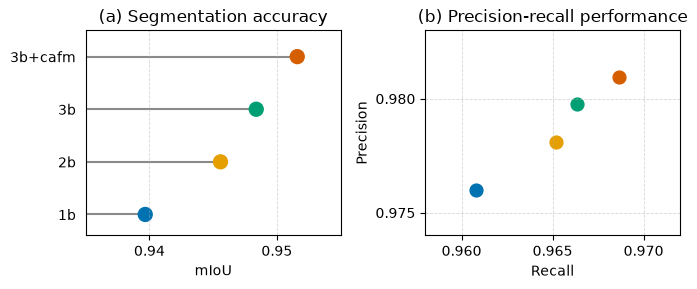

In [7]:
sat_colors = {
    "1b": "#0072B2",  # 蓝
    "2b": "#E69F00",  # 橙
    "3b": "#009E73",  # 绿
    "3b+cafm": "#D55E00",  # 朱红
}

names = list(sat_colors)
acc_model_plot = acc_model.set_axis(names)
metrics_ranked = acc_model_plot.sort_values("miou")

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

### (1) Segmentation accuracy plot
y = np.arange(len(metrics_ranked))
values = metrics_ranked["miou"]

axes[0].hlines(y, 0.935, values, color="#8A8A8A", linewidth=1.5, zorder=1)
axes[0].scatter(values, y, s=100,
                c=[sat_colors[name] for name in metrics_ranked.index])

axes[0].set(xlim=(0.935, 0.955), ylim=(-0.4, 3.5), yticks=y, yticklabels=metrics_ranked.index, xlabel="mIoU") ;
axes[0].set_title("(a) Segmentation accuracy")
axes[0].grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.5) 
axes[0].tick_params(left=False)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(0.01))


### (2) Precision-recall performance plot
for name, row in metrics_ranked.iterrows():
    axes[1].scatter(
        row["recall"], row["precision"],
        s=85, color=sat_colors[name], label=name)

# axes[1].plot([0.96, 0.99], [0.96, 0.99], 
#              color="#8A8A8A", linestyle="--",
#              linewidth=1)

axes[1].set(xlim=(0.958, 0.972), ylim=(0.974, 0.983), 
            xlabel="Recall", ylabel="Precision", title="(b) Precision-recall performance")
axes[1].yaxis.set_major_locator(mticker.MultipleLocator(0.005))
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(0.005))
axes[1].grid(linestyle="--", linewidth=0.6, alpha=0.5)

# axes[1].legend(loc="lower left", fontsize=10, frameon=False)
plt.tight_layout()




### (2) data ablation


In [8]:
dir_result_no_dem = 'data/result/ablation_data/u3net_timm_remove_dem/'
dir_result_no_rgb = 'data/result/ablation_data/u3net_timm_remove_rgb/'
dir_result_no_ir = 'data/result/ablation_data/u3net_timm_remove_ir/'
dir_result_3branch_cafm = 'data/result/u3net_cross_fusion/'
paths_val_result_no_dem = sorted(glob.glob(dir_result_no_dem + '*.tif'))
paths_val_result_no_rgb = sorted(glob.glob(dir_result_no_rgb + '*.tif'))
paths_val_result_no_ir = sorted(glob.glob(dir_result_no_ir + '*.tif'))
paths_val_result_3branch_cafm = sorted(glob.glob(dir_result_3branch_cafm + '*.tif'))
paths_val_result_3branch_cafm = sorted(glob.glob(dir_result_3branch_cafm + '*.tif'))
print(len(paths_val_result_3branch_cafm))



13


In [9]:
### read results
results_no_dem, results_no_rgb, results_no_ir, results_3b_cafm = [], [], [], []
for path_result_no_dem, path_result_no_rgb, path_result_no_ir, path_result_3b_cafm in zip(paths_val_result_no_dem, paths_val_result_no_rgb, paths_val_result_no_ir, paths_val_result_3branch_cafm):
    with rio.open(path_result_no_dem) as result_rio:
        result_arr = result_rio.read()[0]
        results_no_dem.append(result_arr)
    with rio.open(path_result_no_rgb) as result_rio:
        result_arr = result_rio.read()[0]
        results_no_rgb.append(result_arr)
    with rio.open(path_result_no_ir) as result_rio:
        result_arr = result_rio.read()[0]
        results_no_ir.append(result_arr)
    with rio.open(path_result_3b_cafm) as result_rio:
        result_arr = result_rio.read()[0]
        results_3b_cafm.append(result_arr)


In [10]:
acc_metrics_no_dem = pd.read_csv(dir_result_no_dem + 'metrics_scenes.csv')
acc_metrics_no_rgb = pd.read_csv(dir_result_no_rgb + 'metrics_scenes.csv')
acc_metrics_no_ir = pd.read_csv(dir_result_no_ir + 'metrics_scenes.csv')
acc_metrics_3b_cafm = pd.read_csv(dir_result_3branch_cafm + 'metrics_scenes.csv')
acc_metrics = pd.concat([acc_metrics_no_dem[['Unnamed: 0','miou']], acc_metrics_no_rgb['miou'], acc_metrics_no_ir['miou'], acc_metrics_3b_cafm['miou']], axis=1)
acc_metrics.columns = ['scenes', 'miou_no_dem', 'miou_no_rgb', 'miou_no_ir', 'miou_3b_cafm']
acc_metrics



,scenes,miou_no_dem,miou_no_rgb,miou_no_ir,miou_3b_cafm
0,l5_scene_01,0.923981,0.924590,0.904793,0.927978
1,l5_scene_06,0.905804,0.897821,0.873170,0.918276
2,l5_scene_11,0.985683,0.985068,0.982083,0.987541
3,l7_scene_03,0.962734,0.962273,0.942918,0.963953
4,l7_scene_08,0.970927,0.968287,0.963014,0.971105
5,l7_scene_13,0.953232,0.957216,0.951328,0.960728
6,l8_scene_05,0.892355,0.873973,0.814328,0.897633
7,l8_scene_10,0.971361,0.970883,0.968013,0.975566
8,l9_scene_02,0.977276,0.979458,0.971506,0.977494
9,l9_scene_07,0.786536,0.865410,0.862481,0.888279


#### region selection

In [11]:
### region 1: cloud confusion (ir data)
# i = 1
# extent_local = [75.44, 75.6, 37.5, 37.62]

## region 2:  glacier-connected river ice （rgb data）
i = 7
extent_local = [-29.3, -28.65, 81.76, 81.85]

# ## region 3: glacier on the steep mountains （dem data）
# i = 9
# extent_local = [98.89, 99, 31.71, 31.8]     

## region 4: ?
# i = 12
# extent_local = [98.87, 99, 31.81, 31.92]     

## identify the scene coordinates and extent    
scene_src = scenes_rio[i]
epsg = scenes_rio[i].crs.to_epsg()
src_crs = ccrs.epsg(epsg)
extent_scene = [scene_src.bounds.left, scene_src.bounds.right, scene_src.bounds.bottom, scene_src.bounds.top]
print(extent_scene)



[446460.0, 498150.0, 9059040.0, 9111870.0]


scenes          l8_scene_10
miou_no_dem        0.971361
miou_no_rgb        0.970883
miou_no_ir         0.968013
miou_3b_cafm       0.975566
Name: 7, dtype: object


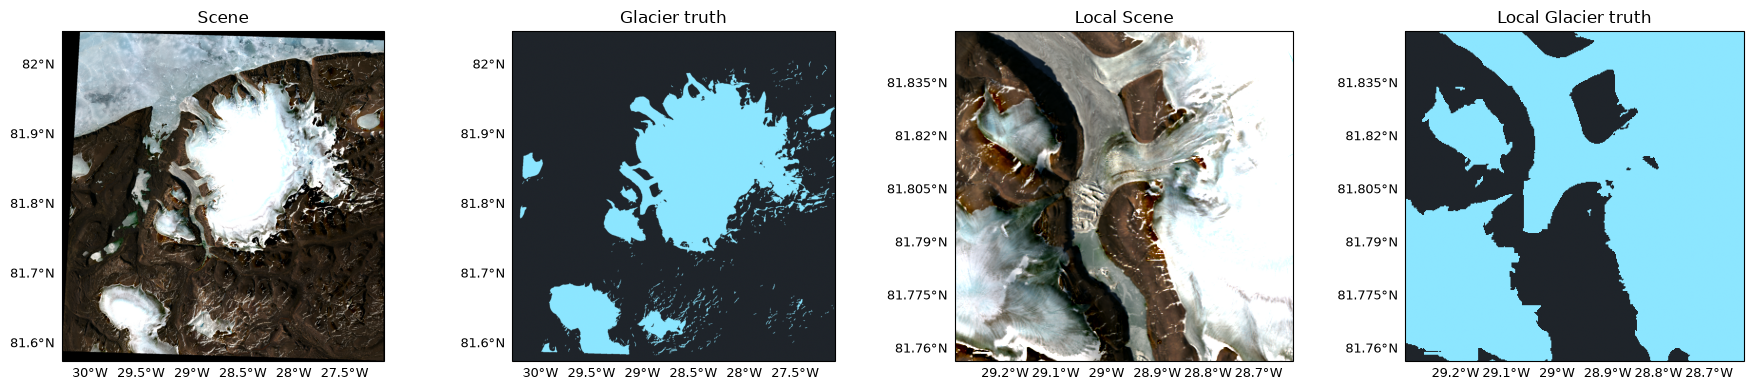

In [12]:
### show the scene and truth
fig, ax = plt.subplots(1, 4, figsize=(18, 4), subplot_kw={'projection': src_crs})
print(acc_metrics.iloc[i,:])       
## global region
imgShow(scenes_arr[i], color_bands = [2,1,0], clip_percent=[0, 90], extent=extent_scene, transform=src_crs, ax=ax[0])
ax[1].imshow(truths[i], cmap=cmap_gla, vmin=-0.5, vmax=1.5, extent=extent_scene, transform=src_crs)  

## local region
imgShow(scenes_arr[i], color_bands = [2,1,0], clip_percent=[0, 90], extent=extent_scene, transform=src_crs, ax=ax[2])
# ax[2].imshow(dems[i], cmap='terrain', extent=extent_scene, transform=src_crs)
ax[3].imshow(truths[i], cmap=cmap_gla, vmin=-0.5, vmax=1.5, extent=extent_scene, transform=src_crs)  

for j, a in enumerate(ax):
    gl = a.gridlines(draw_labels=True, color="gray", alpha=0.0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"fontsize": 9}    
    gl.ylabel_style = {"fontsize": 9}   
    gl.geo_labels = False   # note: 禁止 Gridliner 调整标题
    # gl.xlocator = mticker.MultipleLocator(0.3)
    # gl.ylocator = mticker.MultipleLocator(0.5)
    if j > 1:  # local region   
        a.set_extent(extent_local, crs=ccrs.PlateCarree())    

ax[0].set_title("Scene")     
ax[1].set_title("Glacier truth")     
ax[2].set_title("Local Scene")      
ax[3].set_title("Local Glacier truth")      
plt.tight_layout()      


In [ ]:
result_no_dem = 2*results_no_dem[i].astype(int) - truths[i]   ##  omission: -1, right non-gla: 0, right glaicer: 1, comission: 2
result_no_rgb = 2*results_no_rgb[i].astype(int) - truths[i]   
result_no_ir = 2*results_no_ir[i].astype(int) - truths[i]   
result_3b_cafm = 2*results_3b_cafm[i].astype(int) - truths[i]     


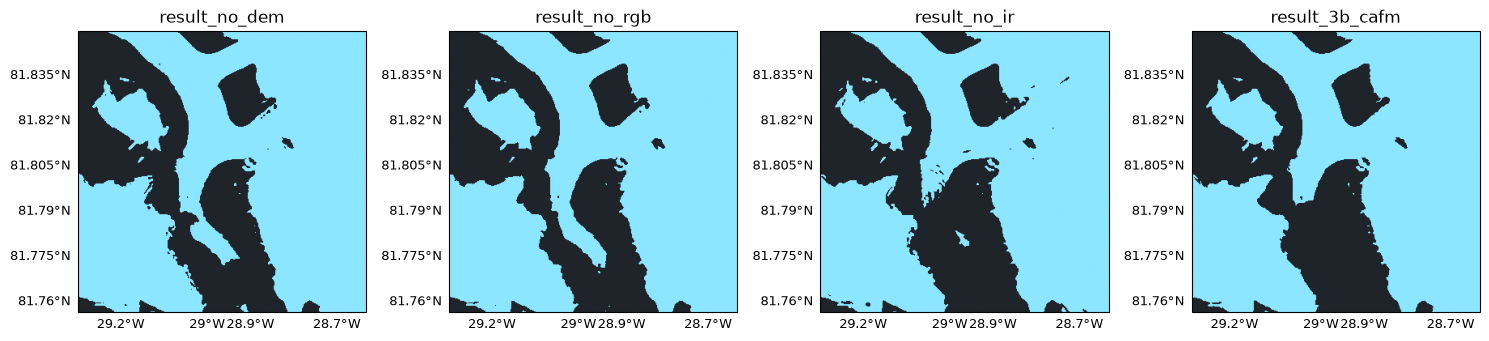

In [14]:
### show the results
fig, ax = plt.subplots(1, 4, figsize=(15, 4), subplot_kw={'projection': src_crs})
imgShow(scenes_arr[i], color_bands = [3,2,1], clip_percent=5, ax =ax[0])
ax[0].imshow(results_no_dem[i], cmap=cmap_gla, vmin=-0.5, vmax=1.5, extent=extent_scene, transform=src_crs)
ax[1].imshow(results_no_rgb[i], cmap=cmap_gla, vmin=-0.5, vmax=1.5, extent=extent_scene, transform=src_crs)
ax[2].imshow(results_no_ir[i], cmap=cmap_gla, vmin=-0.5, vmax=1.5, extent=extent_scene, transform=src_crs)
ax[3].imshow(results_3b_cafm[i], cmap=cmap_gla, vmin=-0.5, vmax=1.5, extent=extent_scene, transform=src_crs)
# ax[0].imshow(result_no_dem, cmap=cmap_result, vmin=-1.5, vmax=2.5, extent=extent_scene, transform=src_crs)
# ax[1].imshow(result_no_rgb, cmap=cmap_result, vmin=-1.5, vmax=2.5, extent=extent_scene, transform=src_crs)
# ax[2].imshow(result_no_ir, cmap=cmap_result, vmin=-1.5, vmax=2.5, extent=extent_scene, transform=src_crs)
# ax[3].imshow(result_3b_cafm, cmap=cmap_result, vmin=-1.5, vmax=2.5, extent=extent_scene, transform=src_crs)

for j, a in enumerate(ax):
    gl = a.gridlines(draw_labels=True, color="gray", alpha=0.0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"fontsize": 9}
    gl.ylabel_style = {"fontsize": 9}
    gl.geo_labels = False      ## 关键: 禁止 Gridliner 调整标题
    # gl.xlocator = mticker.MultipleLocator(1)
    # gl.ylocator = mticker.MultipleLocator(0.2)
    a.set_extent(extent_local, crs=ccrs.PlateCarree())   

ax[0].set_title("result_no_dem")
ax[1].set_title("result_no_rgb")
ax[2].set_title("result_no_ir")
ax[3].set_title("result_3b_cafm") 
plt.tight_layout()

